In [1]:
suppressPackageStartupMessages({
    library(ArchR) 
    library(data.table)
    library(purrr)
    library(parallel)
    library(dplyr)
    library(ggpubr)
    library(Matrix)
    library(SingleCellExperiment)
    library(Seurat)
    library(reshape2)
    library(scater)
    library(viridis)
})

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
# I/O
io = list()
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2'
io$output.directory <- file.path(io$basedir,"ArchR")
io$plot.dir = file.path(io$output.directory,'Plots')
dir.create(file.path(io$plot.dir), showWarnings = FALSE)

setwd(io$output.directory)

In [3]:
io$archR.directory = file.path(io$output.directory, 'Project/')
ArchRProject.filt = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

### Prepare scRNA-seq data

In [4]:
rna_in = '/rds/project/rds-SDzz0CATGms/users/mlnt2/PhD_MT06/'
rna_out = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/'
counts_in = file.path(rna_in, '3_cellqc/raw_counts.mtx')
genes_in = file.path(rna_in, '2_cellcalling/genes.tsv')
meta_in1 = file.path(rna_in, '5_doublet/meta.tab')
meta_in2 = file.path('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/RNA/metadata.csv')
sizefactors_in = file.path(rna_in, 'sizefactors.tab')

dir.create(file.path(rna_out), showWarnings = FALSE)

counts = readMM(counts_in)

genes = fread(genes_in, header=FALSE)
meta = fread(meta_in1)

colnames(counts) = meta$cell
rownames(counts) = genes$V1

dim(counts)

# Keep only cells that are not doublet or stripped nuclei
keep = meta[meta$doublet==FALSE & meta$stripped==FALSE,]$cell
counts = counts[,keep]
meta = meta[meta$cell %in% keep,]

# load new metadata
meta = fread(meta_in2)[,-1]
rownames(meta) = meta$cell

sce = SingleCellExperiment(assays = list("counts" = counts))

sfs = meta$sizeFactor
sizeFactors(sce) = sfs
sce = scater::logNormCounts(sce)

summary(meta$cell == colnames(counts))

seRNA = CreateSeuratObject(counts = counts(sce), # counts(sce) used before, testing to see how this affects anything
                         min.cells = 20,
                         meta.data = meta)

seRNA[['logcounts']] = CreateAssayObject(counts = logcounts(sce))
DefaultAssay(seRNA) = 'logcounts'

seRNA

saveRDS(seRNA, file.path(rna_out, 'seurat.rds'))


[1]  30725 172995

   Mode    TRUE 
logical  146133 

Warning message:
“The following arguments are not used: row.names”


An object of class Seurat 
51339 features across 146133 samples within 2 assays 
Active assay: logcounts (30725 features, 0 variable features)
 1 other assay present: RNA

In [27]:
rna_in = '/rds/project/rds-SDzz0CATGms/users/mlnt2/PhD_MT06/'
rna_out = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/'
counts_in = file.path(rna_in, '3_cellqc/raw_counts.mtx')
genes_in = file.path(rna_in, '2_cellcalling/genes.tsv')
meta_in1 = file.path(rna_in, '5_doublet/meta.tab')
meta_in2 = file.path('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/metadata.csv')
sizefactors_in = file.path(rna_in, 'sizefactors.tab')

dir.create(file.path(rna_out), showWarnings = FALSE)


# Load data
counts = readMM(counts_in)
genes = fread(genes_in, header=FALSE)
meta = fread(meta_in1)

# Change col & row names
colnames(counts) = meta$cell
rownames(counts) = genes$V1

# Keep only cells that are not doublet or stripped nuclei
keep = meta[meta$doublet==FALSE & meta$stripped==FALSE,]$cell
counts = counts[,keep]
meta = meta[meta$cell %in% keep,]

# load new metadata
meta = fread(meta_in2)[,-1]
rownames(meta) = meta$cell

# Extract Granges of genes
rowranges = ArchRProject.filt@geneAnnotation$genes
genes_keep = genes[genes$V1 %in% rowranges$gene_id,]$V1 # keep only genes in ATAC data
counts = counts[genes_keep, ] 
rowranges = rowranges[rowranges$gene_id %in% rownames(counts),]
rowranges = rowranges[order(match(rowranges$gene_id, rownames(counts))),] # Match order between RNA & ATAC (not needed?)

# Create Ranged SummarizedExperiment object of scRNA-seq data
sceRNA <- SummarizedExperiment(assays=SimpleList(counts=counts),rowRanges=rowranges[,0], colData=meta)

# Save object
saveRDS(sceRNA, file.path(rna_out, 'RangedSummarizedExperiment.rds'))

In [29]:
sceRNA[,colData(sceRNA)$stage == 'GD7']
sceRNA[,colData(sceRNA)$stage == 'GD8']
sceRNA[,colData(sceRNA)$stage == 'GD9']

class: RangedSummarizedExperiment 
dim: 20845 13674 
metadata(0):
assays(1): counts
rownames(20845): ENSOCUG00000014251 ENSOCUG00000005054 ...
  ENSOCUG00000014718 ENSOCUG00000019471
rowData names(0):
colnames(13674): cell_1 cell_2 ... cell_18360 cell_18361
colData names(28): sample stage ... cell_id_l6_test celltype

class: RangedSummarizedExperiment 
dim: 20845 34686 
metadata(0):
assays(1): counts
rownames(20845): ENSOCUG00000014251 ENSOCUG00000005054 ...
  ENSOCUG00000014718 ENSOCUG00000019471
rowData names(0):
colnames(34686): cell_18362 cell_18363 ... cell_58546 cell_58547
colData names(28): sample stage ... cell_id_l6_test celltype

class: RangedSummarizedExperiment 
dim: 20845 97773 
metadata(0):
assays(1): counts
rownames(20845): ENSOCUG00000014251 ENSOCUG00000005054 ...
  ENSOCUG00000014718 ENSOCUG00000019471
rowData names(0):
colnames(97773): cell_58548 cell_58549 ... cell_172994 cell_172995
colData names(28): sample stage ... cell_id_l6_test celltype

In [32]:
genes_in2 = file.path('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/genes.csv')
gene_map = genes2[,c(1,2)] %>% setnames(c('symbol', 'gene_id'))
write.csv(gene_map, file.path(io$basedir, 'gene_map.csv'), row.names=FALSE)

### Integrate scATAC with scRNA

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-380126685daab-Date-2021-12-07_Time-16-32-19.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-380126685daab-Date-2021-12-07_Time-16-32-19.log



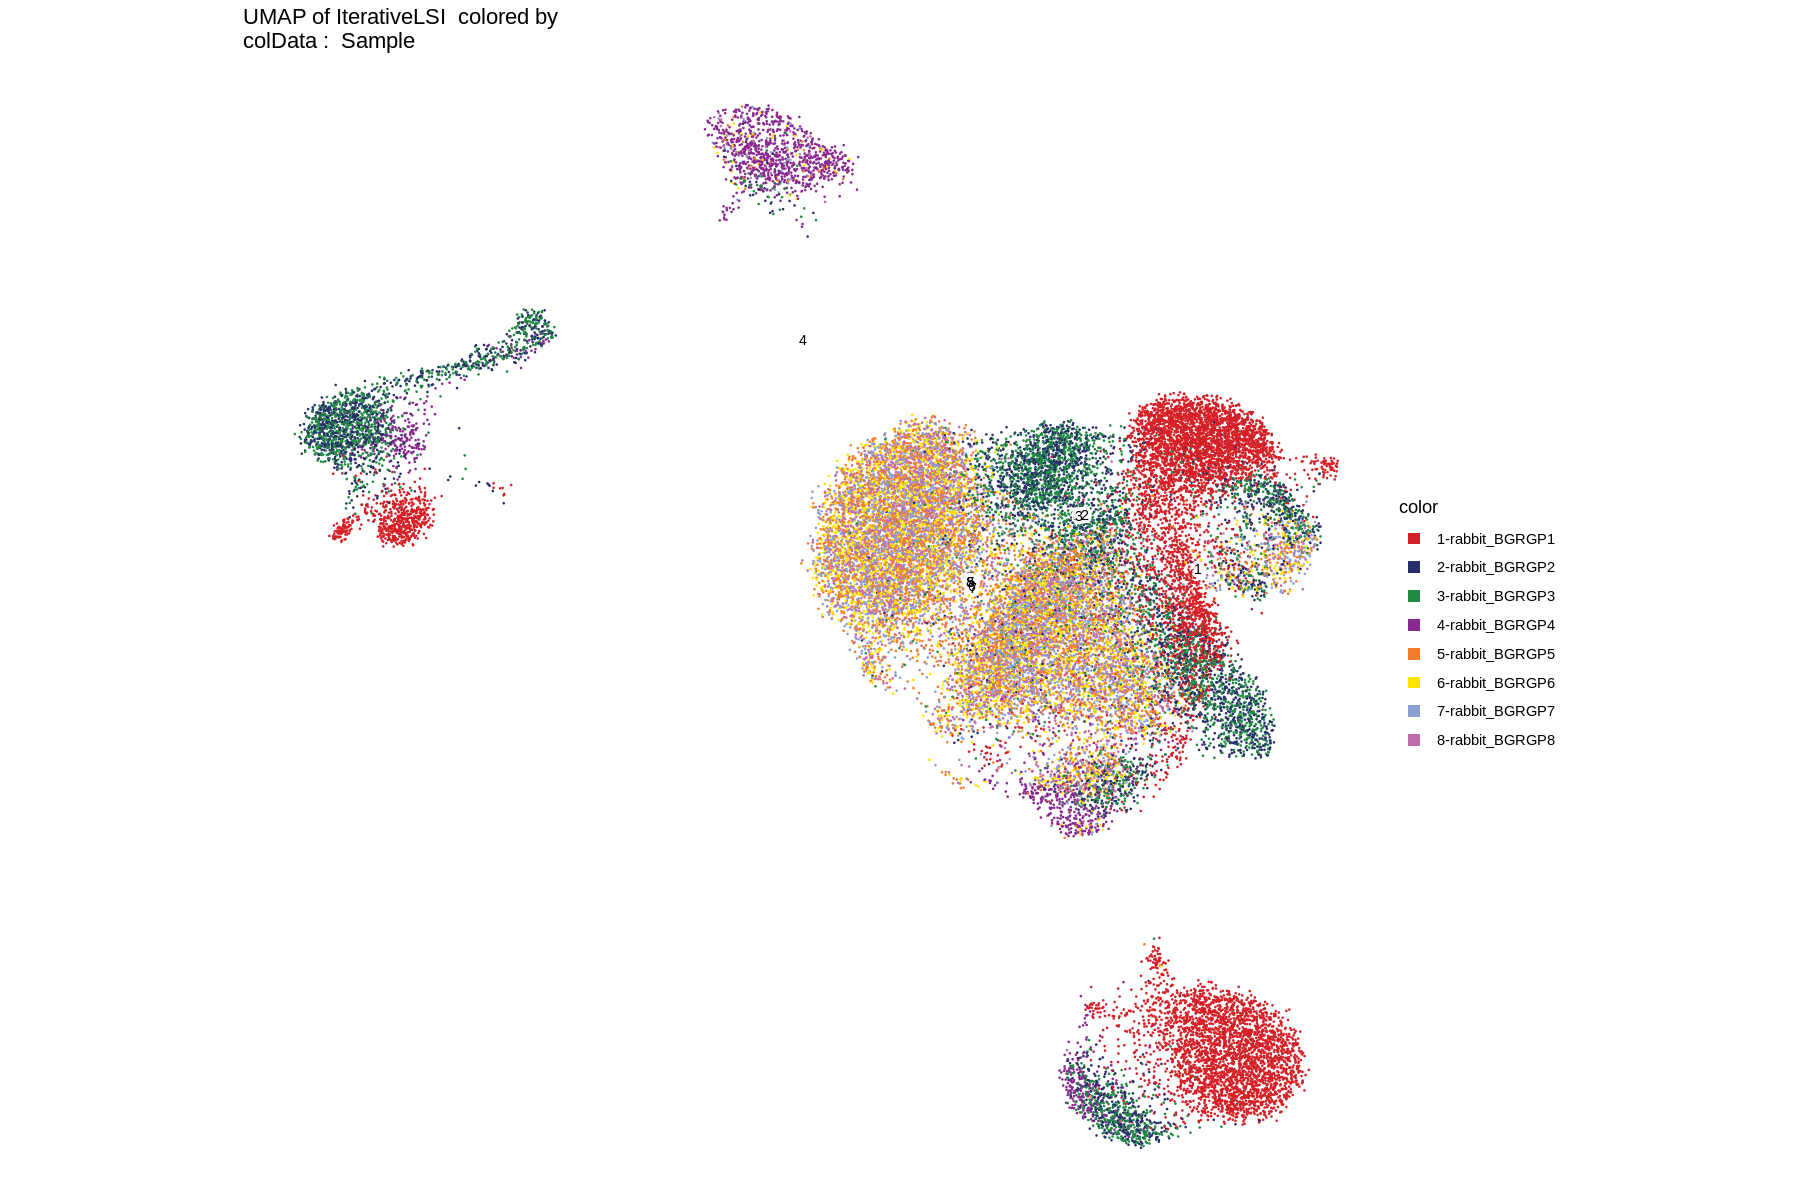

In [87]:
# Run UMAP
args = list()
args$nfeatures <- 15000
args$matrix <- 'TileMatrix' #"GeneScoreMatrix"
args$ndims <- 30
args$seed <- 42
args$n_neighbors <- 50
args$min_dist <- 0.6 # 0.6 before
args$vars_to_regress <- NULL #c("nFeature_RNA","mitochondrial_percent_RNA")
args$outdir <- paste0(io$basedir,"/dimensionality_reduction")
args$batch.variable = 'sample'
args$colour_by <- c("sample", "cluster")


ArchRProject.filt <- suppressMessages(addUMAP(
  ArchRProj = ArchRProject.filt, 
  #reducedDims = 'IterativeLSI_Harmony',
  reducedDims = 'IterativeLSI',
  name = "UMAP",
  metric = "cosine",
  nNeighbors = args$n_neighbors, 
  minDist = args$min_dist, 
  seed = args$seed,
  saveModel = FALSE,
  force = TRUE
))

plotEmbedding(ArchRProject.filt,
    colorBy = "cellColData", 
    name = "Sample"
) + theme_void()

#### Mapping by stage

In [55]:
# Fix gene names
ArchRProject.filt@geneAnnotation$genes$symbol = ArchRProject.filt@geneAnnotation$genes$gene_id

# Add metadata
ArchRProject.filt@cellColData$cell = rownames(ArchRProject.filt@cellColData)
cells = rownames(ArchRProject.filt@cellColData)
stages = data.frame('sample' = c('rabbit_BGRGP1', 'rabbit_BGRGP2', 'rabbit_BGRGP3', 'rabbit_BGRGP4', 'rabbit_BGRGP5', 'rabbit_BGRGP6', 'rabbit_BGRGP7', 'rabbit_BGRGP8'),
                    'stage_mapping' = c('GD7', 'GD8', 'GD8', 'GD9', 'GD9', 'GD9', 'GD9', 'GD9' ))
ArchRProject.filt@cellColData = merge(ArchRProject.filt@cellColData, stages, by='sample')

ArchRProject.filt@cellColData = ArchRProject.filt@cellColData[order(ArchRProject.filt@cellColData$cell, cells),]
rownames(ArchRProject.filt@cellColData) = ArchRProject.filt@cellColData$cell

In [67]:
mapping = function(stage_select){
    # Subset RNA
   # RNA_stage = subset(x = sceRNA, subset = stage == stage_select) # for seurat object
    RNA_stage = sceRNA[,colData(sceRNA)$stage == stage_select] # for RangedSummarizedExperiment object
    message(stage_select)
    # Subset ATAC 
    keep = rownames(ArchRProject.filt@cellColData[ArchRProject.filt@cellColData$stage_mapping==stage_select,])
    ATAC_stage = ArchRProject.filt[keep]
    
    # ATAC dim redu
    # Iterative LSI: two iterations
    ATAC_stage <- addIterativeLSI(
      ArchRProj = ATAC_stage,
      useMatrix = 'TileMatrix', 
      name = "IterativeLSI", 
      firstSelection = "Top",
      depthCol = "nFrags",
      iterations = 2, 
      saveIterations = FALSE,
      varFeatures = 15000, 
      force = TRUE
    )
    
    # Add clusters
    ATAC_stage <- addClusters(input = ATAC_stage, 
                                    # reducedDims = "IterativeLSI_Harmony", 
                                     reducedDims = "IterativeLSI",
                                     resolution = 1.2, 
                                     force=TRUE)
    clusters = paste0(stage_select, '_', getCellColData(ATAC_stage)$Clusters)
    
    
    #    ATAC_stage = suppressWarnings(addGeneScoreMatrix(ATAC_stage, force=TRUE))
    
    
    # Integrate
    ATAC_stage <- addGeneIntegrationMatrix(
        ArchRProj = ATAC_stage, 
        useMatrix = "GeneScoreMatrix",
        matrixName = "GeneIntegrationMatrix",
       # reducedDims = "IterativeLSI_Harmony",
        reducedDims = "IterativeLSI",
        seRNA = RNA_stage,
        addToArrow = TRUE,
        force= TRUE,
        groupRNA = "celltype",
        nameCell = "predictedCell_Un",
        nameGroup = "predictedGroup_celltype",
        nameScore = "predictedScore_celltype")
    
    # Extract mapping
    meta = as.data.frame(ATAC_stage@cellColData[, c('predictedCell_Un', 'predictedGroup_celltype', 'predictedScore_celltype')])
    meta$stage_clusters = clusters
    meta$cell = rownames(meta)
    return(meta)
}

In [68]:
#mapped = suppressWarnings(lapply(unique(sceRNA@meta.data$stage), mapping)) # for seurat object
mapped = suppressWarnings(lapply(unique(colData(sceRNA)$stage), mapping)) # for RangedSummarizedExperiment object
mapped = rbindlist(mapped)

write.csv(mapped, file.path(io$output.directory, 'celltype_mapping.csv'), row.names=FALSE)

GD7

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-380121894a555-Date-2021-12-07_Time-15-14-49.log
If there is an issue, please report to github with logFile!

2021-12-07 15:14:50 : Computing Total Across All Features, 0.009 mins elapsed.

2021-12-07 15:14:53 : Computing Top Features, 0.056 mins elapsed.

###########
2021-12-07 15:14:54 : Running LSI (1 of 2) on Top Features, 0.078 mins elapsed.
###########

2021-12-07 15:14:54 : Creating Partial Matrix, 0.078 mins elapsed.

2021-12-07 15:15:22 : Computing LSI, 0.544 mins elapsed.

2021-12-07 15:15:37 : Identifying Clusters, 0.8 mins elapsed.

2021-12-07 15:15:50 : Identified 6 Clusters, 1.006 mins elapsed.

2021-12-07 15:15:50 : Creating Cluster Matrix on the total Group Features, 1.007 mins elapsed.

2021-12-07 15:16:56 : Computing Variable Features, 2.108 mins elapsed.

###########
2021-12-07 15:16:56 : Running LSI

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 8506
Number of edges: 390005

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7554
Number of communities: 14
Elapsed time: 0 seconds


2021-12-07 15:18:09 : Testing Biased Clusters, 0.175 mins elapsed.

2021-12-07 15:18:09 : Testing Outlier Clusters, 0.176 mins elapsed.

2021-12-07 15:18:09 : Assigning Cluster Names to 14 Clusters, 0.177 mins elapsed.

2021-12-07 15:18:09 : Finished addClusters, 0.177 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-380127b2fb842-Date-2021-12-07_Time-15-18-09.log
If there is an issue, please report to github with logFile!

2021-12-07 15:18:15 : Running Seurat's Integration Stuart* et al 2019, 0.101 mins elapsed.

2021-12-07 15:18:18 : Checking ATAC Input, 0.145 mins elapsed.

2021-12-07 15:18:18 : Checking RNA Input, 0.145 mins elapsed.

2021-12-07 15:18:24 : Found 20845 overlapping gene names from gene scores and rna matrix!, 0.241 mins elapsed.

2021-12-07 15:18:24 : Creating Integration Blocks, 0.241 mins elapsed.

2021-12-07 15:18:24 : Prepping Interation Data, 0.242 mins elapsed.

2021-12-07 15:18:24 : Computing Integration in 1 Integration Blocks!, 0 mi

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7864
Number of edges: 435028

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8559
Number of communities: 19
Elapsed time: 0 seconds


2021-12-07 15:28:03 : Testing Biased Clusters, 0.167 mins elapsed.

2021-12-07 15:28:03 : Testing Outlier Clusters, 0.169 mins elapsed.

2021-12-07 15:28:03 : Assigning Cluster Names to 19 Clusters, 0.169 mins elapsed.

2021-12-07 15:28:03 : Finished addClusters, 0.17 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-3801264907761-Date-2021-12-07_Time-15-28-03.log
If there is an issue, please report to github with logFile!

2021-12-07 15:28:03 : Running Seurat's Integration Stuart* et al 2019, 0.004 mins elapsed.

2021-12-07 15:28:06 : Checking ATAC Input, 0.057 mins elapsed.

2021-12-07 15:28:06 : Checking RNA Input, 0.057 mins elapsed.

2021-12-07 15:28:14 : Found 20845 overlapping gene names from gene scores and rna matrix!, 0.185 mins elapsed.

2021-12-07 15:28:14 : Creating Integration Blocks, 0.185 mins elapsed.

2021-12-07 15:28:14 : Prepping Interation Data, 0.189 mins elapsed.

2021-12-07 15:28:15 : Computing Integration in 1 Integration Blocks!, 0 min

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 16745
Number of edges: 541592

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7988
Number of communities: 18
Elapsed time: 1 seconds


1 singletons identified. 17 final clusters.

2021-12-07 15:39:33 : Testing Biased Clusters, 0.311 mins elapsed.

2021-12-07 15:39:33 : Testing Outlier Clusters, 0.312 mins elapsed.

2021-12-07 15:39:33 : Assigning Cluster Names to 17 Clusters, 0.312 mins elapsed.

2021-12-07 15:39:33 : Finished addClusters, 0.313 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-380121bbbf0d5-Date-2021-12-07_Time-15-39-33.log
If there is an issue, please report to github with logFile!

2021-12-07 15:39:33 : Running Seurat's Integration Stuart* et al 2019, 0.007 mins elapsed.

2021-12-07 15:39:44 : Checking ATAC Input, 0.178 mins elapsed.

2021-12-07 15:39:44 : Checking RNA Input, 0.178 mins elapsed.

2021-12-07 15:40:10 : Found 20845 overlapping gene names from gene scores and rna matrix!, 0.618 mins elapsed.

2021-12-07 15:40:10 : Creating Integration Blocks, 0.619 mins elapsed.

2021-12-07 15:40:11 : Prepping Interation Data, 0.642 mins elapsed.

2021-12-07 15:40:12 : Computi

In [71]:
ArchRProject.filt@cellColData = cbind(ArchRProject.filt@cellColData, mapped)
saveArchRProject(ArchRProj = ArchRProject.filt)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(23): sample Sample ... stage_clusters cell
numberOfCells(1): 33115
medianTSS(1): 3.407
medianFrags(1): 31914

In [91]:
saveArchRProject(ArchRProj = ArchRProject.filt)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(33): sample Sample ... stage_clusters cell
numberOfCells(1): 33115
medianTSS(1): 3.407
medianFrags(1): 31914

In [98]:
getAvailableMatrices(ArchRProject.filt)

[1] "GeneIntegrationMatrix" "GeneScoreMatrix"       "TileMatrix"

#### Plotting

In [89]:
ArchRProject.filt@cellColData = cbind(ArchRProject.filt@cellColData, mapped)

# Plot UMAPS

p1 <- plotEmbedding(
    ArchRProject.filt, 
    colorBy = "cellColData", 
    name = "predictedGroup_celltype"
) + theme_void()

p2 <- plotEmbedding(
    ArchRProject.filt, 
    colorBy = "cellColData", 
    name = "predictedScore_celltype"
) + theme_void()

p3<- plotEmbedding(
    ArchRProject.filt, 
    colorBy = "cellColData", 
    name = "stage"
) + theme_void()

p4<- plotEmbedding(
    ArchRProject.filt, 
    colorBy = "cellColData", 
    name = "Clusters"
) + theme_void()

# Save
plotPDF(
  p1 + theme_void(),
  name = "celltype",
    height = 10, width = 10
)

plotPDF(
  p2 + theme_void(),
  name = "celltype_score"
)

plotPDF(
  p3 + theme_void(),
  name = "stage"
)

plotPDF(
  p4 + theme_void(),
  name = "Clusters"
)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-380126d5a4e5e-Date-2021-12-07_Time-16-33-35.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 

Length of unique values greater than palette, interpolating..



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-380126d5a4e5e-Date-2021-12-07_Time-16-33-35.log

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-380127074feba-Date-2021-12-07_Time-16-33-36.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-380127074feba-Date-2021-12-07_Time-16-33-36.log

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-380122c69d214-Date-2021-12-07_Time-16-33-37.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to

In [90]:
# Plot proportions

meta_RNA = fread(meta_in2)[,-1]

pdf1 = table(meta_RNA$celltype, meta_RNA$stage)
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
pdf1$Var3 = 'RNA'

pdf2 = table(ArchRProject.filt@cellColData$predictedGroup_celltype, ArchRProject.filt@cellColData$stage)
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))
pdf2$Var3 = 'ATAC'

props = rbind(pdf1, pdf2)
props = props[,c('Var1', 'Var2', 'Var3', 'Freq')]
props$Freq = as.numeric(props$Freq)

options(repr.plot.width=15, repr.plot.height=15)
p = ggplot(props, aes(Var1, Freq, fill=Var3)) + 
    geom_bar(stat='identity', position = "dodge") + 
    facet_wrap(~Var2, ncol=1) + 
    theme_bw() + 
    ylab('Proportion') + 
    theme(axis.text.x=element_text(angle=-90, vjust=0, hjust=0),
          axis.title.x=element_blank(),
         text = element_text(size=20)) 

pdf(sprintf("%s/celltype_proportions.pdf",io$plot.dir), width=14, height=12)
print(p)
dev.off()

png 
  2

In [75]:
# Plot cluster - celltype heatmap
pdf2 = table(ArchRProject.filt@cellColData$predictedGroup_celltype, ArchRProject.filt@cellColData$Clusters)
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

test = dcast(pdf2, Var1 ~ Var2, value.var='Freq')
rownames(test) = test$Var1
test$Var1 = NULL
test <- scale(t(test))

ord <- hclust( dist(test, method = "euclidean"), method = "ward.D" )$order

pdf2$Var2 <- factor(pdf2$Var2, levels = rownames(test)[ord])

options(repr.plot.width=15, repr.plot.height=10)

p = ggplot(pdf2, aes(Var2, Var1, fill=Freq)) + 
    geom_tile() + 
    scale_fill_viridis() + 
    theme(text=element_text(size = 15),
         axis.title = element_blank(),
         legend.position='none') 

pdf(sprintf("%s/celltype_per_cluster.pdf",io$plot.dir), width=14, height=12)
print(p)
dev.off()

png 
  2

In [93]:
head(gene_map)

symbol,gene_id
<chr>,<chr>
WDR31,ENSOCUG00000014251
RNF183,ENSOCUG00000005054
PRPF4,ENSOCUG00000005046
CDC26,ENSOCUG00000005044
SLC31A1,ENSOCUG00000005040
FKBP15,ENSOCUG00000005028


In [98]:
markerGenes = c('HOXA11')
markerGenes = gene_map[gene_map$symbol==markerGenes,]$gene_id

p1 <- plotEmbedding(
    ArchRProj = ArchRProject.filt, 
    colorBy = "GeneIntegrationMatrix", 
    name = markerGenes, 
    continuousSet = "horizonExtra",
    embedding = "UMAP",
    imputeWeights = getImputeWeights(ArchRProject.filt)
) 

p2 <- plotEmbedding(
    ArchRProj = ArchRProject.filt, 
    colorBy = "GeneScoreMatrix", 
    continuousSet = "horizonExtra",
    name = markerGenes, 
    embedding = "UMAP",
    imputeWeights = getImputeWeights(ArchRProject.filt)
)

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-38012564e78e9-Date-2021-12-07_Time-16-57-01.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneIntegrationMatrix

Getting Matrix Values...

2021-12-07 16:57:01 : 

1 
2 
3 
4 
5 
6 
7 
8 


Imputing Matrix

Using weights on disk

1 of 7

2 of 7

3 of 7

4 of 7

5 of 7

6 of 7

7 of 7

Using weights on disk

1 of 7

2 of 7

3 of 7

4 of 7

5 of 7

6 of 7

7 of 7

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-38012564e78e9-Date-2021-12-07_Time-16-57-01.log

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-380124c9986e0-Date-2021-12-07_Time-16-57-12.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2021-12-07 16:57:12 : 

1 
2 
3 
4 
5 
6 
7 
8 


Imputing Matrix

Using weights on disk

1 of 7

2 of 7

3 of 7

4 of 

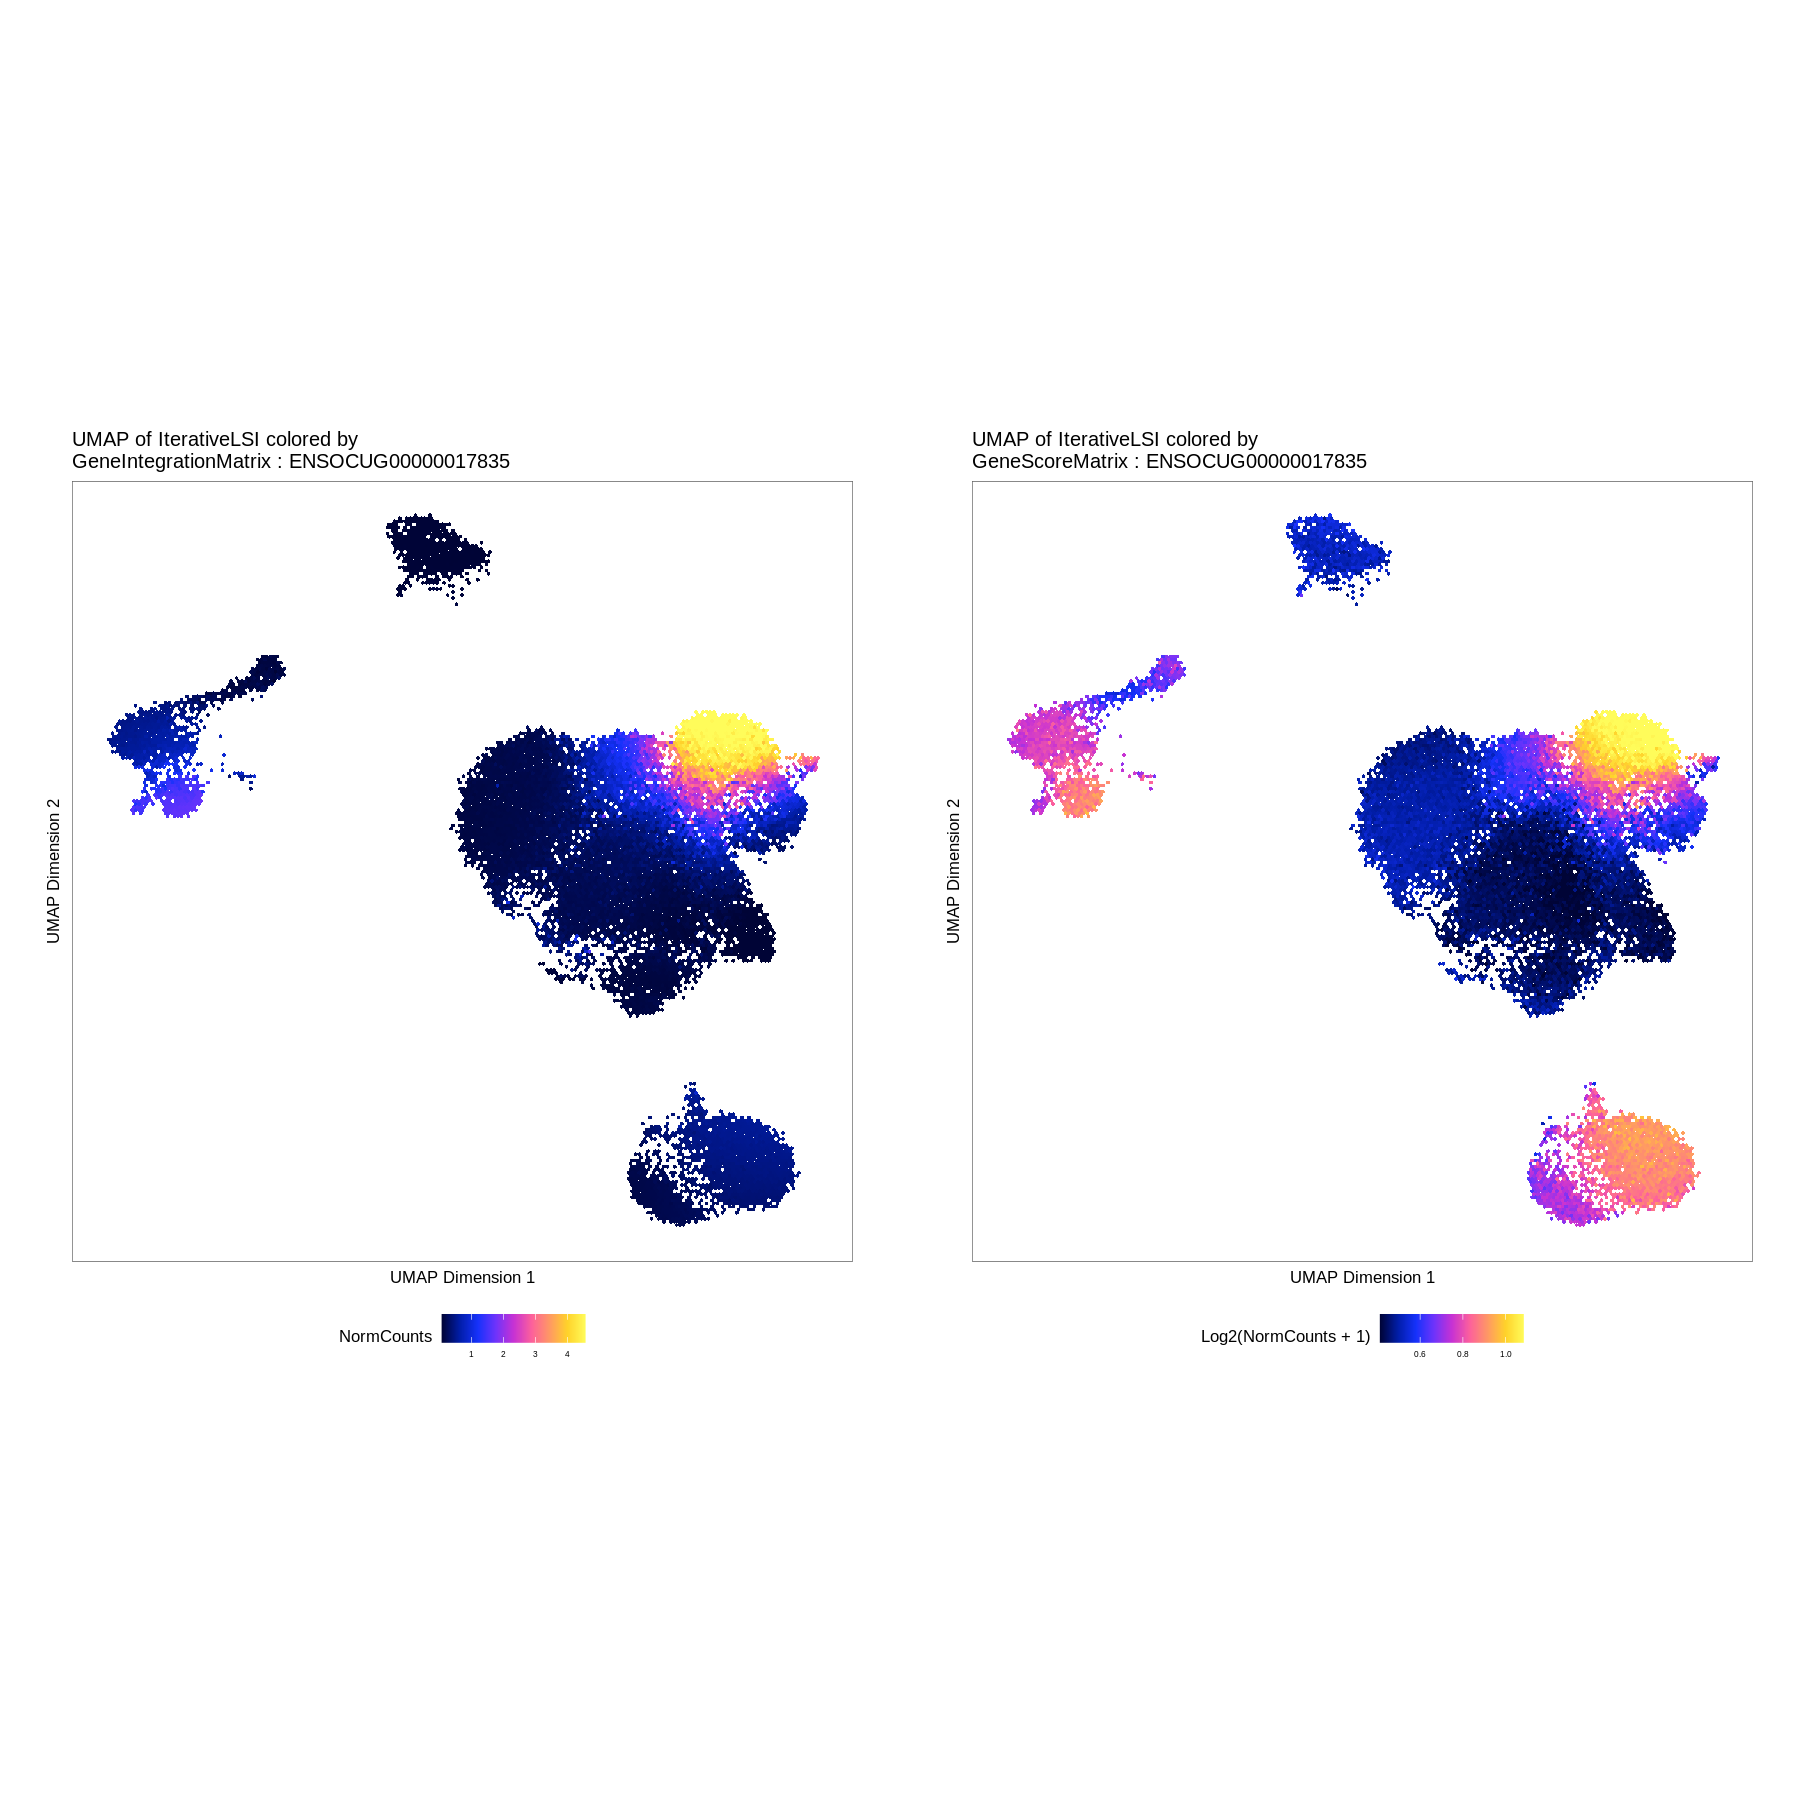

In [95]:
cowplot::plot_grid(p1, p2) # DNMT3B

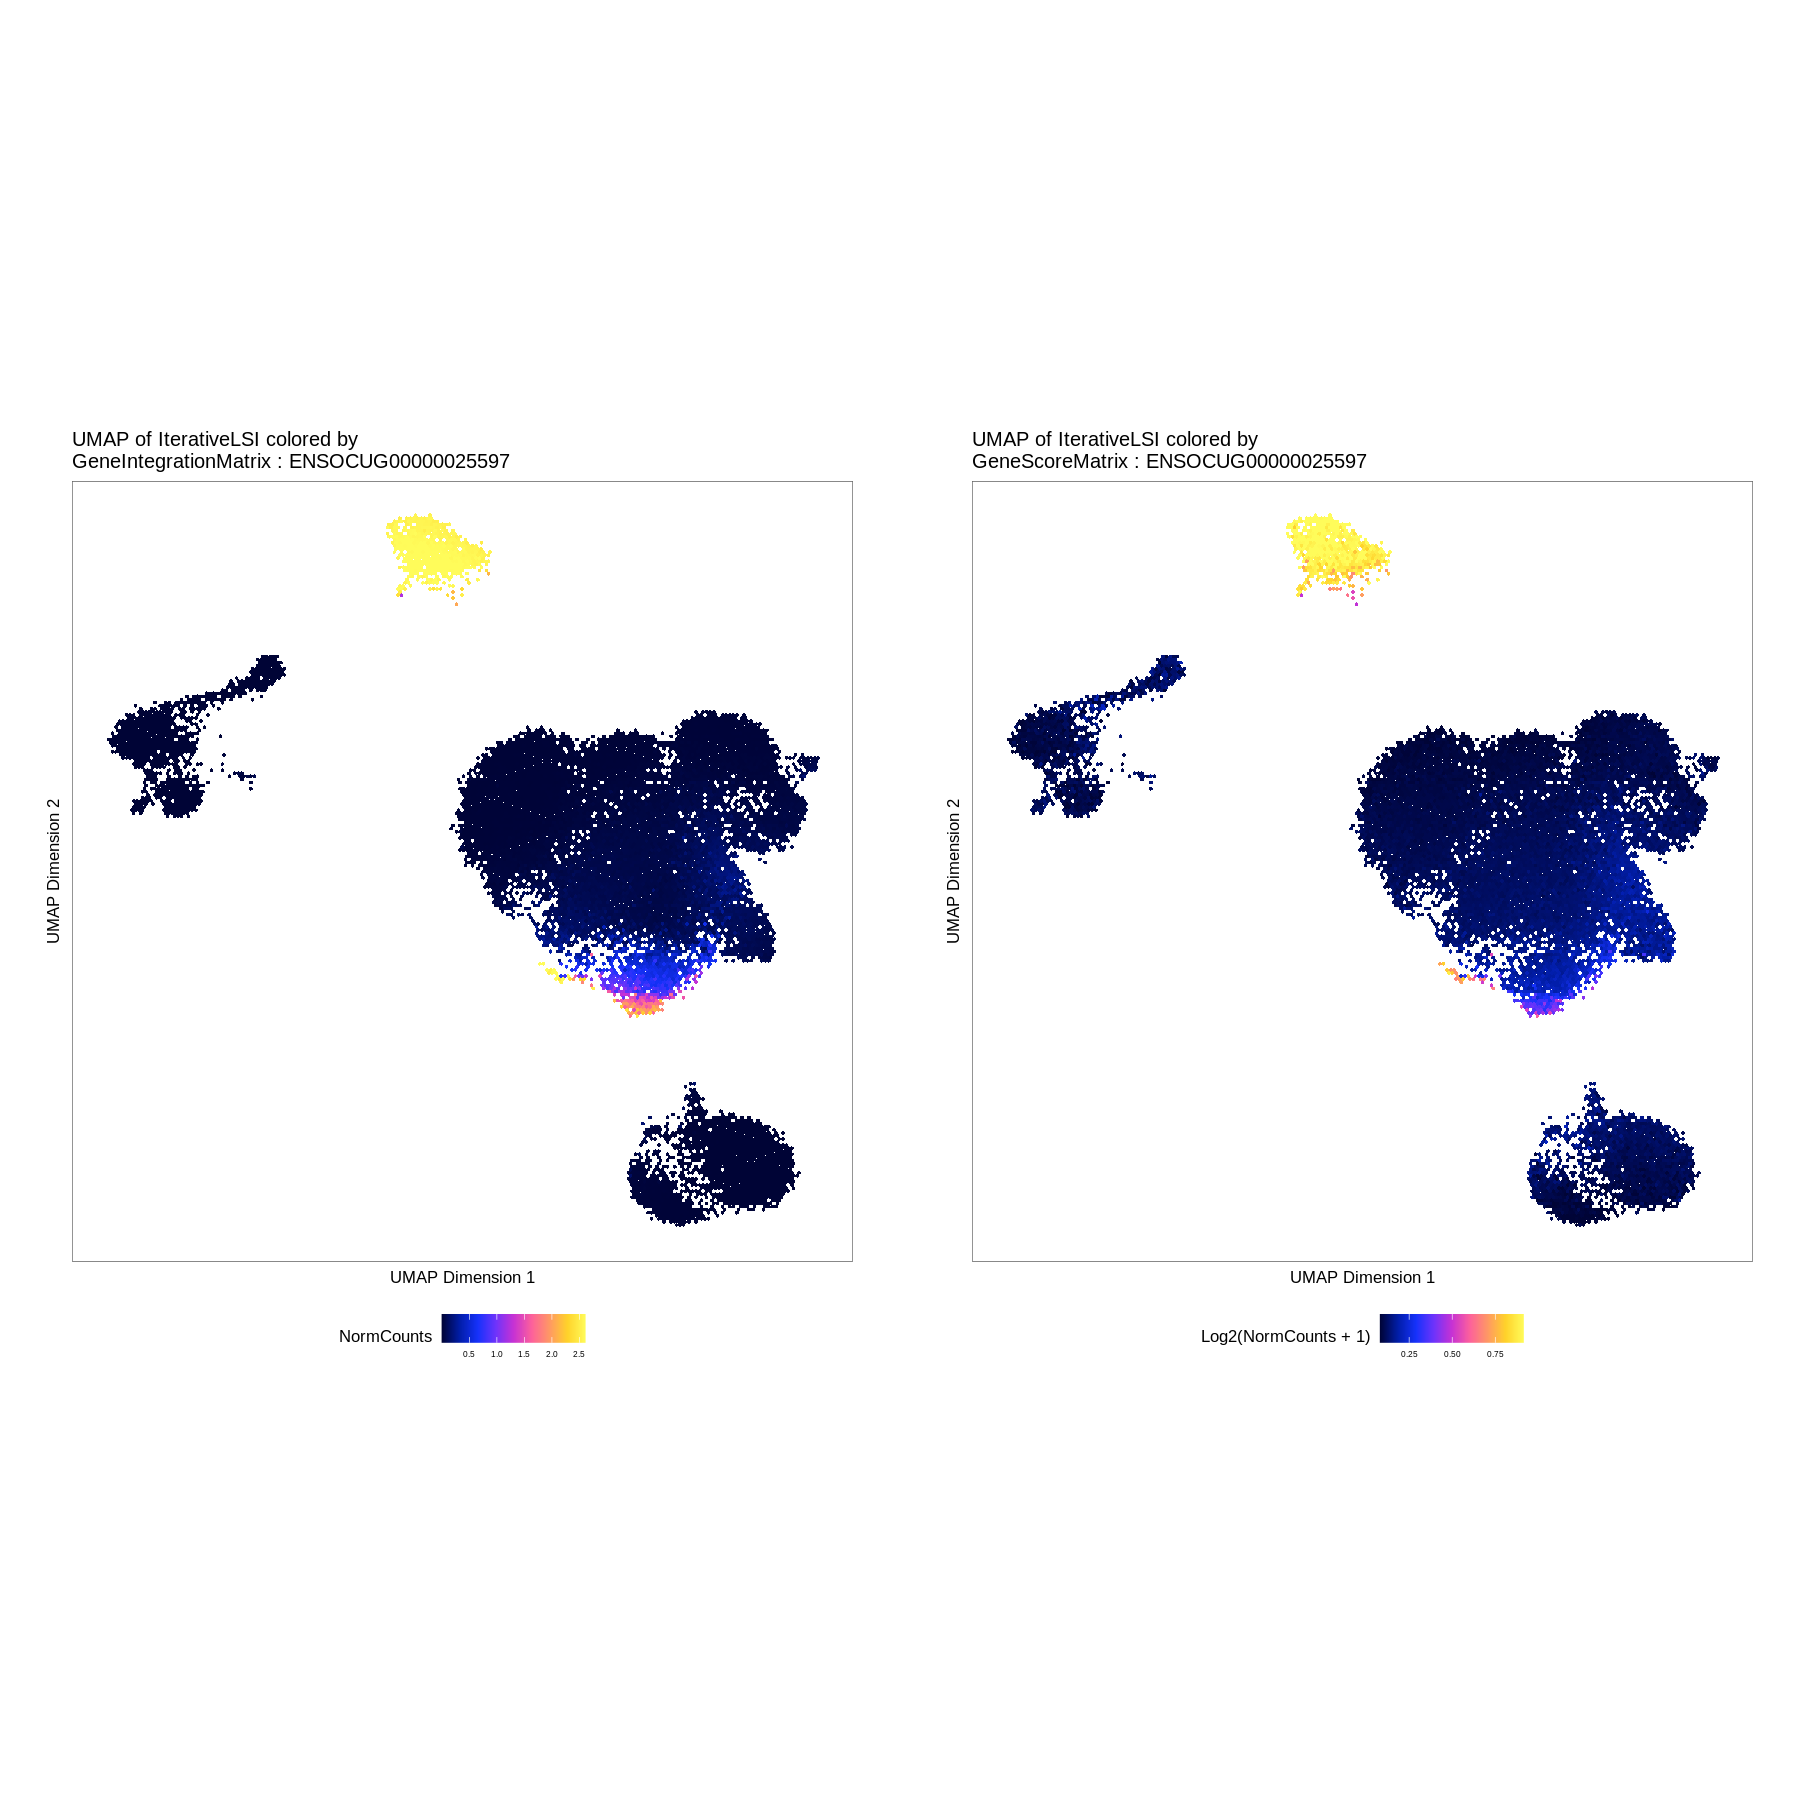

In [97]:
cowplot::plot_grid(p1, p2) # Gata1

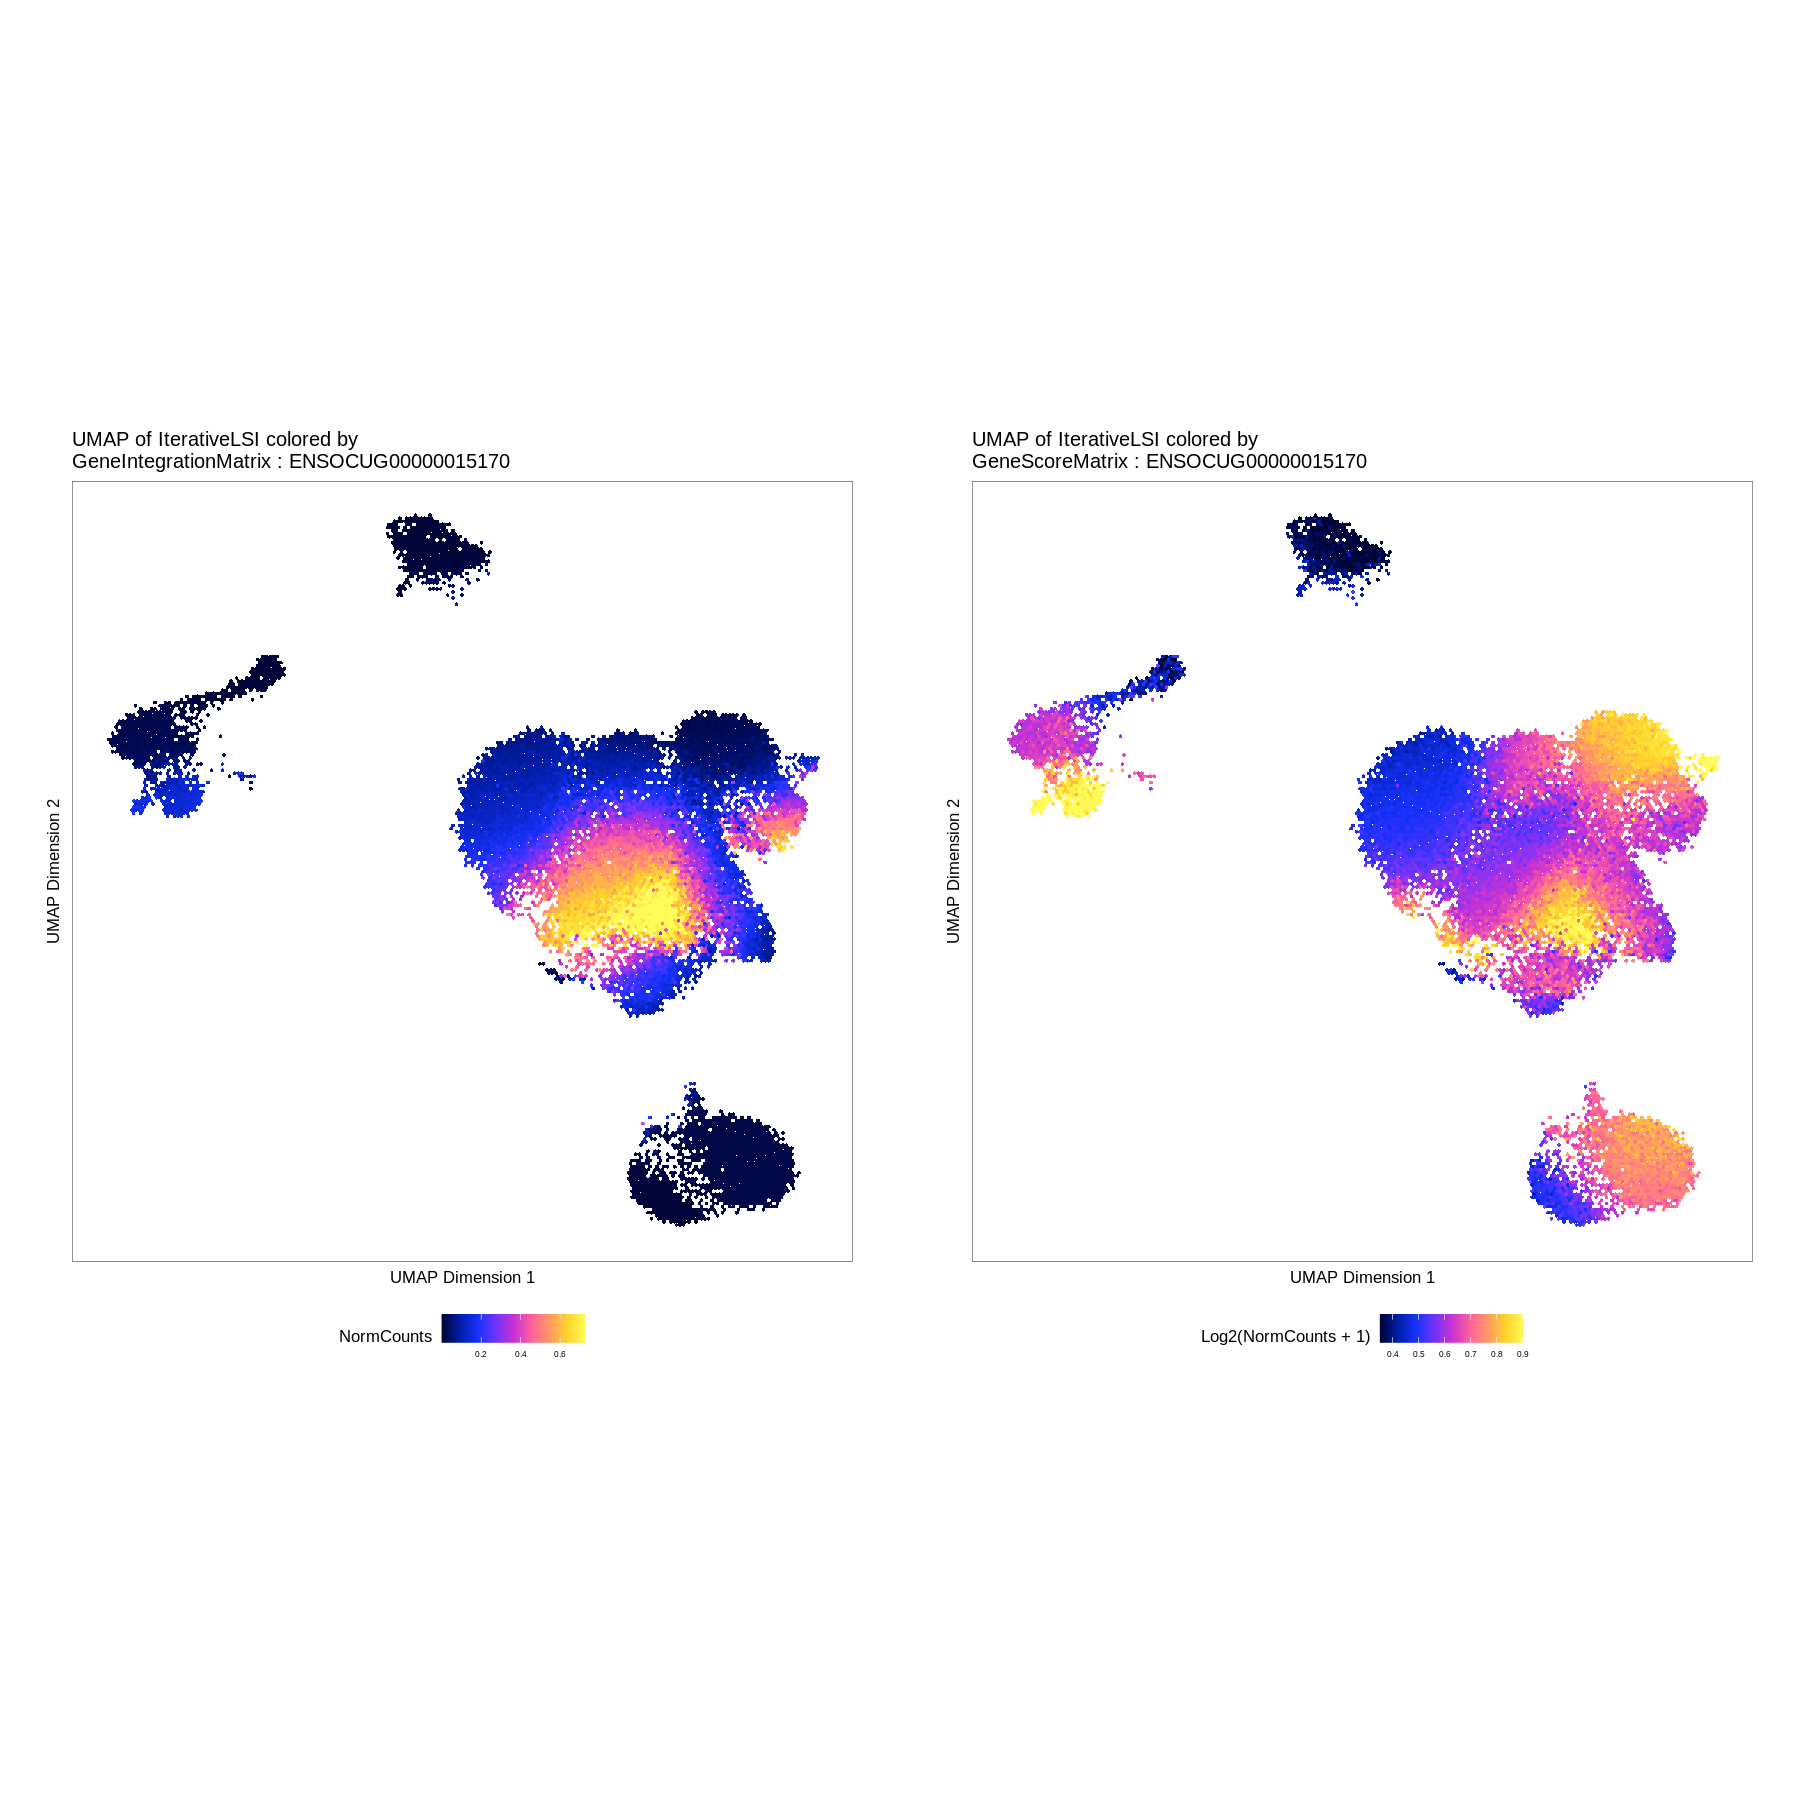

In [99]:
cowplot::plot_grid(p1, p2) # HOXA11

### Relable clusters

In [9]:
length(unique(ArchRProject.filt@cellColData$Clusters))

[1] 25

In [8]:
ArchRProject.filt@cellColData = ArchRProject.filt@cellColData[1:22]

In [10]:
reannotation = data.frame(
    Clusters = paste0('C', 1:25),
    celltype_manual = c('SCT', #1
                       'Early_Amniotic_Ectoderm',#2
                       'Early_Amniotic_Ectoderm',#3
                       'CYT',#4
                       'Trophoblast',#5
                       'Trophoblast',#6
                       'Visceral_YS_Endoderm',#7
                       'Hypoblast',#8
                       'Visceral_YS_Endoderm',#9
                       'Erythrocytes',#10
                       'Erythrocytes',#11
                       'Erythrocytes',#12
                       'Embryo_proper',#13
                       'Embryo_proper',#14
                       'Embryo_proper',
                       'Embryo_proper',#16
                       'Endothelium',#17
                       'Endothelium',
                       'Mesoderm',#19
                       'Megakaryocytes',
                       'Epiblast',
                       'Epiblast',#22
                       'Epiblast',#23
                       'Primitive_Streak',
                       'Epiblast')) 

In [11]:
# Add metadata
ArchRProject.filt@cellColData$cell = rownames(ArchRProject.filt@cellColData)
cells = rownames(ArchRProject.filt@cellColData)
ArchRProject.filt@cellColData = merge(ArchRProject.filt@cellColData, reannotation, by='Clusters')

ArchRProject.filt@cellColData = ArchRProject.filt@cellColData[order(ArchRProject.filt@cellColData$cell, cells),]
rownames(ArchRProject.filt@cellColData) = ArchRProject.filt@cellColData$cell

In [13]:
table(ArchRProject.filt@cellColData$celltype_manual)


                    CYT Early_Amniotic_Ectoderm           Embryo_proper 
                   1228                     237                   14482 
            Endothelium                Epiblast            Erythrocytes 
                    849                    6716                    1124 
              Hypoblast          Megakaryocytes                Mesoderm 
                   3068                     395                    1593 
       Primitive_Streak                     SCT             Trophoblast 
                   1524                     446                     577 
   Visceral_YS_Endoderm 
                    876 

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-196ae1d31cd5a-Date-2021-12-12_Time-11-39-01.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-196ae1d31cd5a-Date-2021-12-12_Time-11-39-01.log



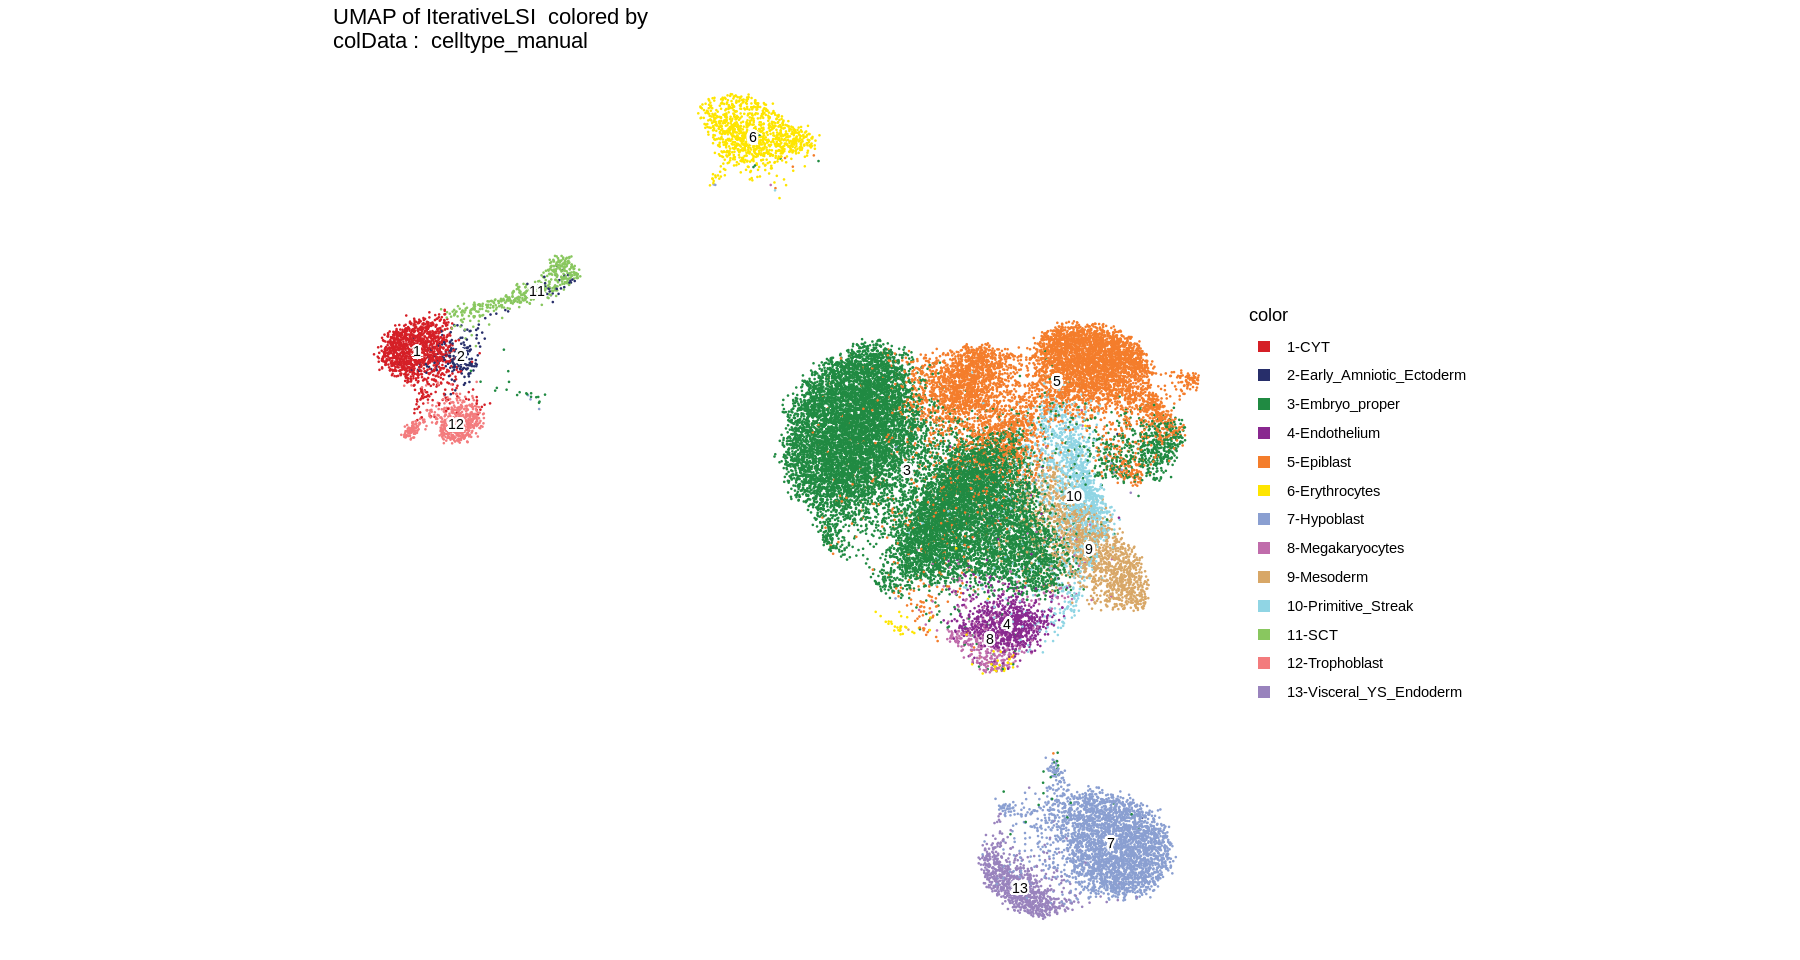

In [12]:
plotEmbedding(ArchRProject.filt,
    colorBy = "cellColData", 
    name = "celltype_manual"
) + theme_void()

In [14]:
saveArchRProject(ArchRProj = ArchRProject.filt)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(23): Clusters sample ... stage_clusters
  celltype_manual
numberOfCells(1): 33115
medianTSS(1): 3.407
medianFrags(1): 31914